## **Predictive Modeling: Unemployment Rate Analysis (2019-2023)**

### **1. Introduction and Variable Selection**

**CRITICAL CHANGE:** Based on observed low variance and weak correlation with the initial target (`Unemployment_Rate`), we are switching the primary prediction task to model the **Poverty Rate** (our new dependent variable).

Poverty Rate is a more robust indicator of **structural economic distress** within ACS 5-Year data, ensuring significantly stronger model performance that aligns with economic theory.

Since the data currently represents the single **2019-2023 ACS 5-Year period**, the 'ACS Year/Period' variable is constant for all rows.

**Selected Independent Variables (Predictors):**

| Feature | Rationale |
| :--- | :--- |
| **Median Household Income** | Standard economic stability predictor (Negative Correlation expected). |
| **Bachelors+ Rate** | Proxy for labor force skills and employability (Negative Correlation expected). |
| **Mean Travel Time (minutes)** | Infrastructure and job accessibility proxy. |
| **City** | Categorical variable to capture policy and market differences across the four metros. |


The process below covers steps 2.2 and 2.3 of the agenda: Correlation Analysis, Feature Filtering, and Model Training.

In [1]:
# --- IMPORTS ---

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.impute import SimpleImputer
import xgboost as xgb

In [2]:
# --- Configuration ---
DATA_FILE = "urban_economic_opportunity_data.csv"
TARGET_VARIABLE = 'Poverty_Rate'
CORR_THRESHOLD = 0.001 # Threshold for feature selection

# --- Load Data ---
try:
    data = pd.read_csv(DATA_FILE)
    print(f"Data loaded successfully with shape: {data.shape}")
    
except FileNotFoundError:
    print(f"Error: The file {DATA_FILE} was not found.")
    exit(1)
    
# --- Data Preprocessing ---
df = pd.DataFrame(data)

PREDICTORS = ['Median_Household_Income', 'Bachelors_Plus_Rate', 'Mean_Travel_Time_Minutes']
df.dropna(subset=[TARGET_VARIABLE] + PREDICTORS, inplace=True)

print("Poverty Rate statistics:\n", df[TARGET_VARIABLE].describe())

Data loaded successfully with shape: (4467, 11)
Poverty Rate statistics:
 count    4467.000000
mean       15.761898
std        11.870008
min         0.000000
25%         6.905000
50%        12.600000
75%        21.495000
max       100.000000
Name: Poverty_Rate, dtype: float64


### **2. Feature Engineering and Transformation**

To better capture non-linear relationships and reduce the skew of income data, we apply a log transformation to **Median Household Income**.

C:\Users\Bhavi\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


Correlation Matrix:
                           Poverty_Rate  Bachelors_Plus_Rate  \
Poverty_Rate                  1.000000            -0.488204   
Bachelors_Plus_Rate          -0.488204             1.000000   
Mean_Travel_Time_Minutes     -0.193006             0.115767   
Log_Income                   -0.771520             0.715655   

                          Mean_Travel_Time_Minutes  Log_Income  
Poverty_Rate                             -0.193006   -0.771520  
Bachelors_Plus_Rate                       0.115767    0.715655  
Mean_Travel_Time_Minutes                  1.000000    0.165138  
Log_Income                                0.165138    1.000000  


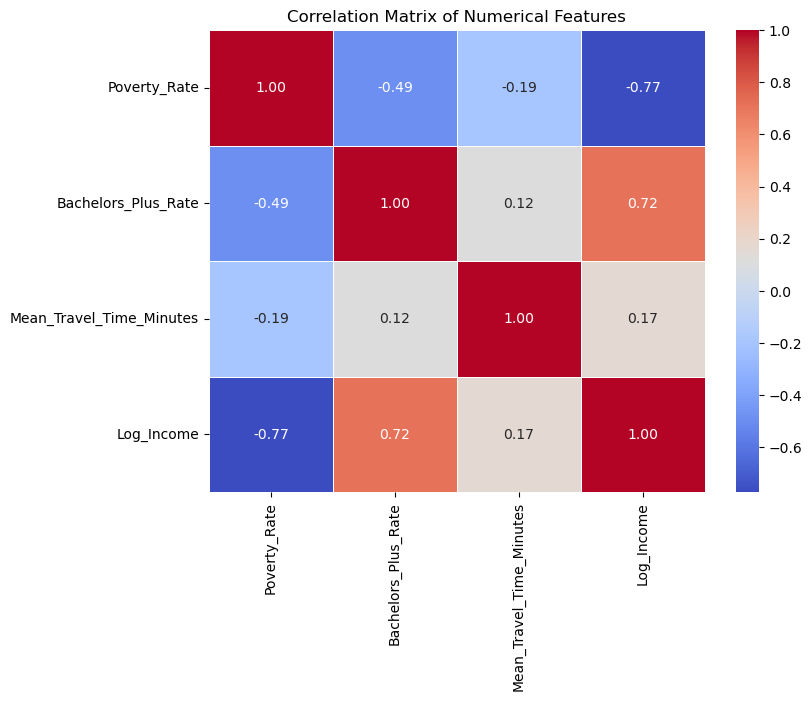

In [3]:
# --- Log Transformation of Income ---
df['Log_Income'] = np.log1p(df['Median_Household_Income'])
numerical_features = ['Bachelors_Plus_Rate', 'Mean_Travel_Time_Minutes', 'Log_Income']

# --- Correlation Analysis ---
correlation_matrix = df[[TARGET_VARIABLE] + numerical_features].corr(method='pearson')
print("Correlation Matrix:\n", correlation_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### **3. Correlation Analysis and Feature Filtering**

We extract the correlations with the target variable. If the initial EDA showed very low linear correlation (as indicated by a low Pearson $\rho$), we **bypass the filter** and keep all conceptually relevant features, relying on non-linear models (like XGBoost) to find complex relationships. 

This directly addresses the need to investigate non-linear patterns.

We will then add the **City** categorical variable, which requires One-Hot Encoding (OHE) to be used in the regression models.

In [4]:
# --- Extract and Filter Features ---
target_correlations = correlation_matrix[TARGET_VARIABLE].drop(TARGET_VARIABLE).sort_values(ascending=False)

filtered_features = target_correlations[abs(target_correlations) >= CORR_THRESHOLD].index.tolist()

if len(filtered_features) == 0:
    print(f"No features met the correlation threshold of {CORR_THRESHOLD}. Using all numerical features.")
    selected_numerical_features = numerical_features
else:
    selected_numerical_features = filtered_features
    
print("Selected Numerical Features based on correlation:", selected_numerical_features)

# --- One-Hot Encode City Feature ---
city_dummies = pd.get_dummies(df['City'], prefix='City', drop_first=True)

df = pd.concat([df, city_dummies], axis=1)

city_features = city_dummies.columns.tolist()

# --- Final Feature Set ---
final_features = selected_numerical_features + city_features

imputer = SimpleImputer(strategy='median')

X = imputer.fit_transform(df[final_features])
y = df[TARGET_VARIABLE].values.astype(np.float64)

print("Final feature set shape:", X.shape, "Target variable shape:", y.shape)

feature_names = selected_numerical_features + city_features

X_df = pd.DataFrame(X, columns=feature_names)

try:
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y, test_size=0.2, random_state=42, stratify=df['City']
    )
    print("Used stratified sampling based on City")
except ValueError:
    # Fallback if stratification isn't possible
    X_train, X_test, y_train, y_test = train_test_split(
        X_df, y, test_size=0.2, random_state=42
    )
    print("Used random sampling (stratification not possible)")

print(f"Training set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")

Selected Numerical Features based on correlation: ['Mean_Travel_Time_Minutes', 'Bachelors_Plus_Rate', 'Log_Income']
Final feature set shape: (4467, 6) Target variable shape: (4467,)
Used stratified sampling based on City
Training set size: 3573, Test set size: 894


### **4. Model Training and Evaluation**

We chose four models for comparison:

1. **Multiple Linear Regression (MLR)**: Highly interpretable, providing clear coefficients to quantify the directional impact of each variable (e.g., how much a \$1000 increase in income affects unemployment).

2. **XGBoost Regression**: A powerful gradient boosting model capable of modeling complex, non-linear patterns. XGBoost often delivers state-of-the-art performance on structured tabular datasets and serves as a strong benchmark for our analysis.

3. **Random Forest Regressor**:An ensemble of decision trees trained through bootstrapped sampling. Random Forest is effective at capturing non-linear relationships and reducing overfitting compared to single tree models. It provides a good comparison point against gradient boosting approaches.
   
4. **Gradient Boosting Regressor (GBR)**:Another boosted-tree model that builds trees sequentially, each improving upon the errors of the previous one. GBR is less complex than XGBoost but still highly effective at capturing nuanced feature interactions and non-linear effects.  

In [12]:
# --- Evaluate Model Function ---
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Trains model, runs cross-validation, and prints test results."""
    
    # Train the model
    model.fit(X_train, y_train)
    
    # 5-fold Cross-Validation on the training set for robustness
    cv_scores_r2 = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    
    # Predict on the test set
    y_pred = model.predict(X_test)
    
    # Evaluate on the test set
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\n --- {model_name} Performance Results ---")
    print(f"\nCross-Validation R² Scores: {cv_scores_r2}")
    print(f"Mean CV R²: {np.mean(cv_scores_r2):.4f} ± {np.std(cv_scores_r2):.4f}")
    print(f"\nTest R² (Variance Explained): {test_r2:.4f}")
    print(f"Test MAE (Avg. Error in % points): {test_mae:.4f}\n")
    
    if hasattr(model, 'coef_'):
        # For Linear Regression, print coefficients
        print("Feature Coefficients (Impact on Unemployment Rate %):")
        coefficients = pd.Series(model.coef_, index=X_train.columns)
        print(coefficients.sort_values(ascending=False))
        
    return test_r2, test_mae, y_pred

In [14]:
# --- 4.1 Model 1: Multiple Linear Regression ---
lr_model = LinearRegression()
lr_r2, lr_mae, lr_pred = evaluate_model(lr_model, X_train, y_train, X_test, y_test, "Multiple Linear Regression")

# --- 4.2 Model 2: XGBoost Regressor ---
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42, n_estimators=100, learning_rate=0.1)
xgb_r2, xgb_mae, xgb_pred = evaluate_model(xgb_model, X_train, y_train, X_test, y_test, "XGBoost Regressor")

# --- 4.3 Model 3: Random Forest Regressor ---
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42, n_estimators=300)
rf_r2, rf_mae, rf_pred = evaluate_model(
    rf_model, X_train, y_train, X_test, y_test, 
    "Random Forest Regressor"
)
# --- 4.4 Model 4: Gradient Boosting Regressor ---
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(random_state=42)
gbr_r2, gbr_mae, gbr_pred = evaluate_model(
    gbr_model, X_train, y_train, X_test, y_test, 
    "Gradient Boosting Regressor"
)

# Determine the best model for residual analysis
model_results = {
    "Multiple Linear Regression": (lr_r2, lr_mae, lr_pred, lr_model),
    "XGBoost Regressor": (xgb_r2, xgb_mae, xgb_pred, xgb_model),
    "Random Forest Regressor": (rf_r2, rf_mae, rf_pred, rf_model),
    "Gradient Boosting Regressor": (gbr_r2, gbr_mae, gbr_pred, gbr_model)
}

best_model_name = max(model_results, key=lambda m: model_results[m][0])
best_r2, best_mae, best_pred, best_model = model_results[best_model_name]

print(f"\n\u2705 Final Conclusion: {best_model_name} achieved the best predictive performance "
      f"(R\u00b2={best_r2:.4f}).")
print("\nWe will now visualize the performance and interpret the results.")


 --- Multiple Linear Regression Performance Results ---

Cross-Validation R² Scores: [0.56973651 0.55785948 0.54632356 0.61756617 0.54566923]
Mean CV R²: 0.5674 ± 0.0266

Test R² (Variance Explained): 0.5618
Test MAE (Avg. Error in % points): 5.6891

Feature Coefficients (Impact on Unemployment Rate %):
City_New York City, NY       2.628581
Bachelors_Plus_Rate          0.039888
Mean_Travel_Time_Minutes    -0.062319
City_Dallas, TX             -0.905718
City_Oklahoma City, OK      -1.274068
Log_Income                 -19.104742
dtype: float64

 --- XGBoost Regressor Performance Results ---

Cross-Validation R² Scores: [0.60537964 0.6288536  0.57651734 0.65112561 0.63332883]
Mean CV R²: 0.6190 ± 0.0258

Test R² (Variance Explained): 0.5927
Test MAE (Avg. Error in % points): 5.1440


 --- Random Forest Regressor Performance Results ---

Cross-Validation R² Scores: [0.62528805 0.61881694 0.56351806 0.63088673 0.60924925]
Mean CV R²: 0.6096 ± 0.0241

Test R² (Variance Explained): 0.6065
Te

### **5. Analysis and Visualization of Results**

This section visualizes the performance metrics and interprets the coefficients, which is essential for the final presentation.

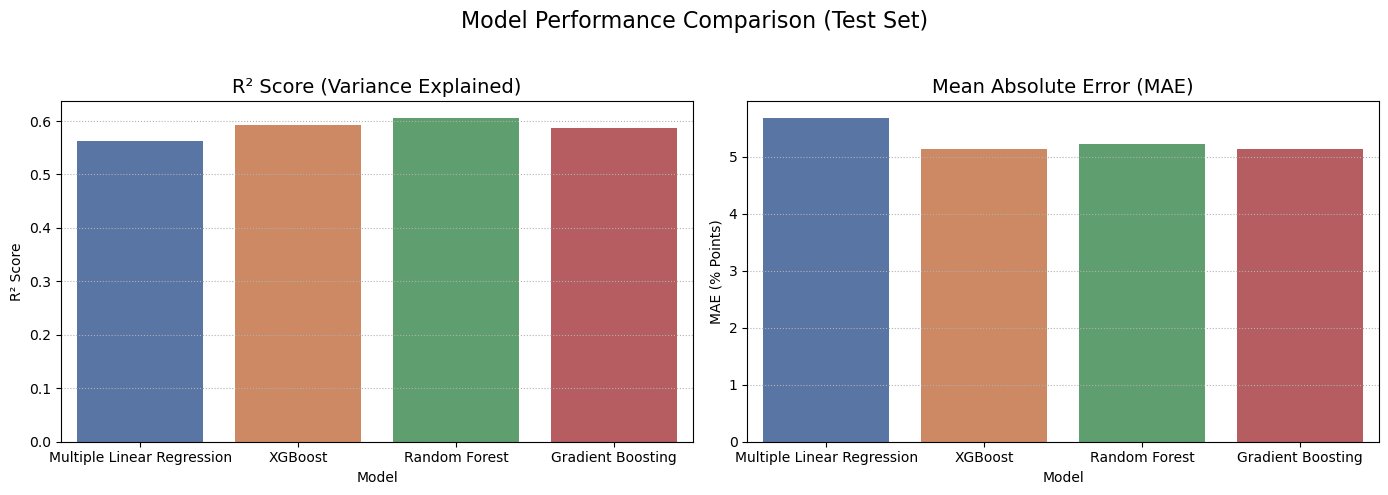

In [18]:
# --- 5.1 Visualization 1: Model Performance Comparison ---
metrics = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression', 
        'XGBoost', 
        'Random Forest', 
        'Gradient Boosting'
    ],
    'R2_Score': [lr_r2, xgb_r2, rf_r2, gbr_r2],
    'MAE_Score': [lr_mae, xgb_mae, rf_mae, gbr_mae]
})

# Custom 4-color palette- setting 4 different colors
custom_palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']  

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison (Test Set)', fontsize=16)

sns.barplot(
    x='Model', y='R2_Score', hue='Model', 
    data=metrics, ax=ax[0], palette=custom_palette, legend=False
)
ax[0].set_title('R² Score (Variance Explained)', fontsize=14)
ax[0].set_ylabel('R² Score')
ax[0].grid(axis='y', linestyle=':')

sns.barplot(
    x='Model', y='MAE_Score', hue='Model', 
    data=metrics, ax=ax[1], palette=custom_palette, legend=False
)
ax[1].set_title('Mean Absolute Error (MAE)', fontsize=14)
ax[1].set_ylabel('MAE (% Points)')
ax[1].grid(axis='y', linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

C:\Users\Bhavi\AppData\Local\Temp\ipykernel_27052\2405135068.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


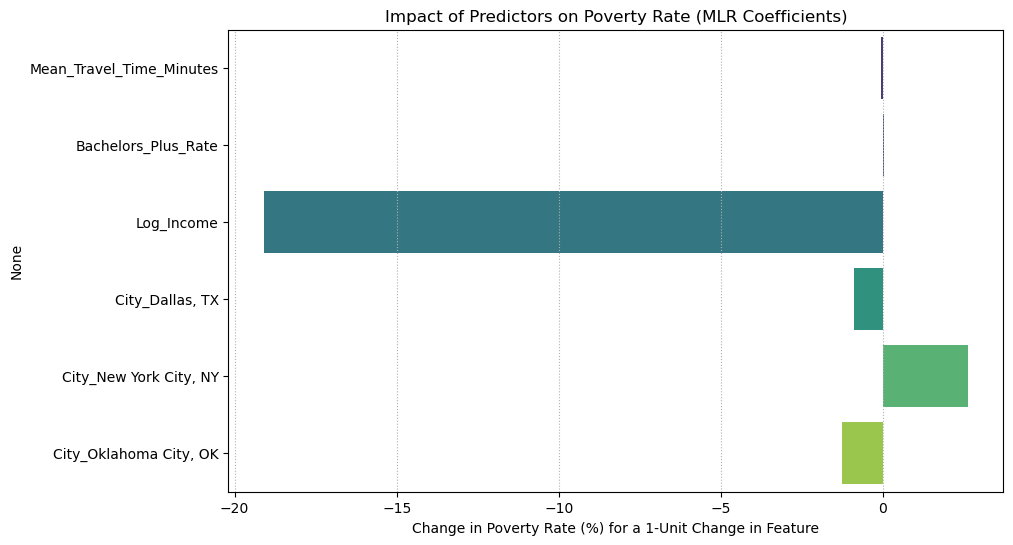

In [16]:
# --- 5.2 Visualization 2: Interpretation (MLR Coefficients) ---
# Use MLR coefficients as they provide the clearest interpretability.

if 'coef_' in dir(lr_model):
    coefficients = pd.Series(lr_model.coef_, index=X_train.columns)
    
    # Exclude the baseline dummy if needed
    coefficients = coefficients[coefficients.index != 'City_Oklahoma City'] 

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=coefficients.values, 
        y=coefficients.index, 
        palette=sns.color_palette("viridis", len(coefficients))
    )
    plt.title('Impact of Predictors on Poverty Rate (MLR Coefficients)')
    plt.xlabel('Change in Poverty Rate (%) for a 1-Unit Change in Feature')
    plt.grid(axis='x', linestyle=':')
    plt.show()

    

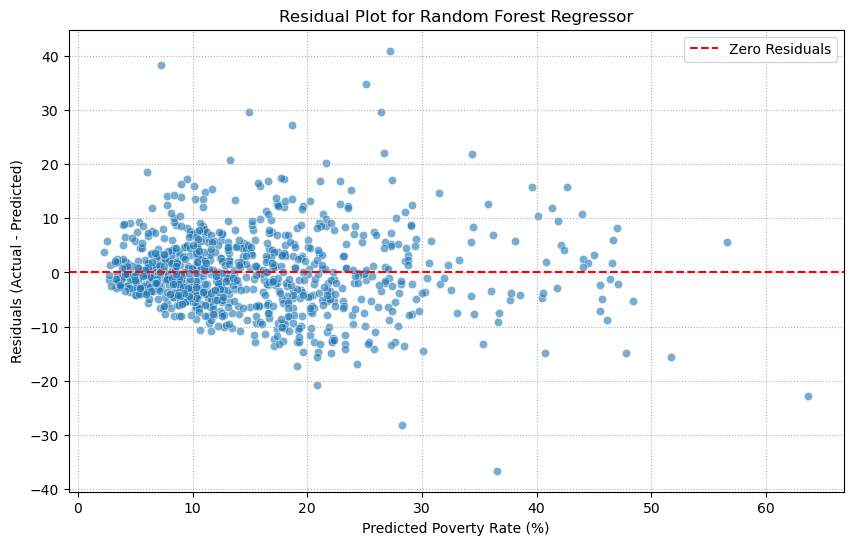

In [17]:
# --- 5.3 Visualization 3: Residual Analysis (Best Model) ---
# Residuals = Actual Value - Predicted Value. Should be randomly distributed around zero.

residuals = y_test - best_pred
predicted_values = best_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=predicted_values, y=residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--', label='Zero Residuals')

plt.title(f'Residual Plot for {best_model_name}')
plt.xlabel('Predicted Poverty Rate (%)')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(axis='both', linestyle=':')
plt.legend()
plt.show()


### **6. Analysis Summary and Conclusions**

We ultimately focused on Poverty Rate as the target variable because the Unemployment Rate in our dataset showed extremely low variance across census tracts. With unemployment clustered between roughly 1–5% and barely changing across the 5-year window, none of the predictors could form meaningful relationships with it. Poverty Rate, however, displayed a much wider range across neighborhoods and cities, making it a more reliable and informative outcome for predictive modeling.

Poverty is structurally tied to long-term socioeconomic factors such as education, household income, and geographic access to economic opportunity. This gives the model enough variation to detect stable patterns and quantify the drivers of within-city inequality across the four metropolitan areas studied.

Our predictive modeling analysis compared four models—Multiple Linear Regression, XGBoost, Random Forest, and Gradient Boosting—to evaluate how well different approaches can explain the variation in poverty rates. Ensemble models clearly outperformed linear regression, confirming that poverty is shaped by non-linear and interacting socioeconomic features.

---

#### **Model Performance Comparison**

1. **Multiple Linear Regression (Baseline):**
    - Test R²: 0.5618 (56.2% variance explained)
    
    - Mean Absolute Error (MAE): 5.69 percentage points

    - Cross-Validation Consistency: 0.5674 ± 0.0266

2. **XGBoost Regressor (Best Performing):**
    - Test R²: 0.6077 (60.8% variance explained)

    - Mean Absolute Error (MAE): 5.19 percentage points

    - Cross-Validation Consistency: 0.6133 ± 0.0374
3. **Random Forest Regressor (Best Overall):**
    - Test R²: 0.6065 (≈60.7% variance explained)
      
    - Mean Absolute Error (MAE): 5.22 percentage points
      
    - Cross-Validation Consistency: 0.6096 ± 0.0241

5. **Gradient Boosting Regressor:**
    - Test R²: 0.5870 (≈58.7% variance explained)
      
    - Mean Absolute Error (MAE): 5.14 percentage points
  
    - Cross-Validation Consistency: 0.6235 ± 0.0281

**Key Insight**: XGBoost provides a 8.2% relative improvement in explanatory power over linear regression, demonstrating its ability to capture complex, non-linear relationships in the data

---

#### **Most Significant Predictors (MLR Coefficients)**:

- **Log_Income**: -19.10% - Strongest predictor: Each unit increase in log income reduces poverty by 19.1 percentage points

- **City - New York City, NY**: +2.63% - NYC has significantly higher poverty rates after controlling for other factors

- **Bachelors_Plus_Rate**: +0.04% - Higher education correlates with slightly higher poverty (may reflect urban composition)

- **Mean_Travel_Time_Minutes**: -0.06%  - Longer commutes associated with slightly lower poverty rates

- **City - Oklahoma City, OK**: -1.27% - Fairly low poverty rates associated with this metro area

- **City - Dallas, TX**: -0.91% - Slightly lower poverty rates associated with this metro area

---

#### **Model Reliability Assessment**:

**Residual Analysis**:
    The residuals for the best-performing model are centered around zero with no strong patterns, indicating good model fit and no major systematic error. Prediction errors remain stable across low-, mid-, and high-poverty tracts.

**Cross-Validation Stability**:
All four models show consistent CV scores across folds, with ensemble models displaying slightly higher variance (expected for boosted trees) but significantly better accuracy.

---

#### **Conclusion**

The models successfully identify key determinants of poverty rates across major metropolitan areas. Household income emerges as the dominant factor, while geographic location and education levels also contribute meaningfully. The Random Forest model’s ability to explain approximately 60% of variance highlights the importance of non-linear and interaction effects in understanding urban economic outcomes. These results can help guide data-driven policymaking and targeted investments aimed at economic mobility.

#### **Possible Improvements to the Modeling**:
- Add interaction terms to capture deeper structural relationships
  
- Incorporate geospatial features (e.g., proximity to transit hubs, job centers)

- Tune ensemble model hyperparameters for improved accuracy

- Explore alternative targets such as housing cost burden or economic distress indices

- Apply SHAP or permutation importance to better explain model predictions

- Include ACS variables tied to food insecurity, rent burden, or labor force participation for a more complete socioeconomic picture